In [4]:
# =============================================================================
# Japan Birth & Death Ratio Analysis (1947–2022)
# Author: Al Rabby Nipu
# Description: Exploratory Data Analysis of Japan demographic trends
#              using birth, death, fertility and population data.
# Dataset: japan_birth.csv (77 rows, 53 columns)
# =============================================================================

In [5]:
# --- Import Libraries ---------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [6]:
# --- Load Dataset -------------------------------------------------------------
df = pd.read_csv("japan_birth.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   year                           76 non-null     float64
 1   birth_total                    76 non-null     float64
 2   birth_male                     76 non-null     float64
 3   birth_female                   76 non-null     float64
 4   birth_rate                     76 non-null     float64
 5   birth_gender_ratio             76 non-null     float64
 6   total_fertility_rate           76 non-null     float64
 7   population_male                76 non-null     float64
 8   population_female              76 non-null     float64
 9   population_total               76 non-null     float64
 10  total_death                    76 non-null     float64
 11  death_rate(CDR)                76 non-null     float64
 12  Life_expectancy_at_birth       76 non-null     float

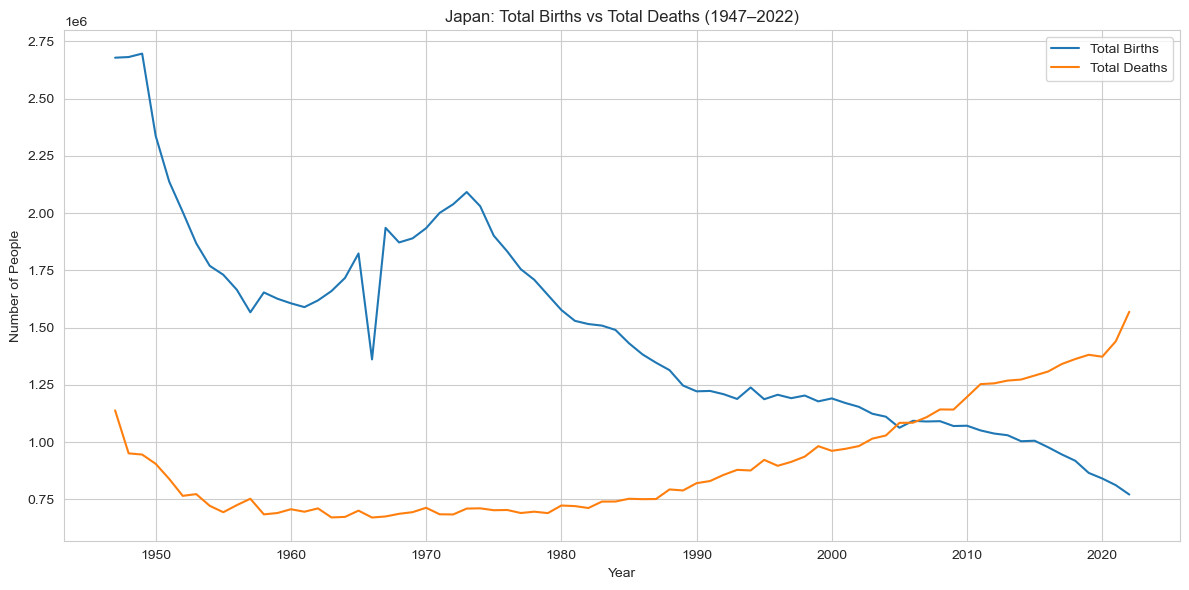

In [7]:
# =============================================================================
# Analysis 1 — Total Births vs Total Deaths (1947–2022)
# =============================================================================
plt.figure(figsize=(12, 6))
plt.plot(df['year'], df['birth_total'], label='Total Births')
plt.plot(df['year'], df['total_death'], label='Total Deaths')
plt.title("Japan: Total Births vs Total Deaths (1947–2022)")
plt.xlabel("Year")
plt.ylabel("Number of People")
plt.legend()
plt.tight_layout()
plt.show()

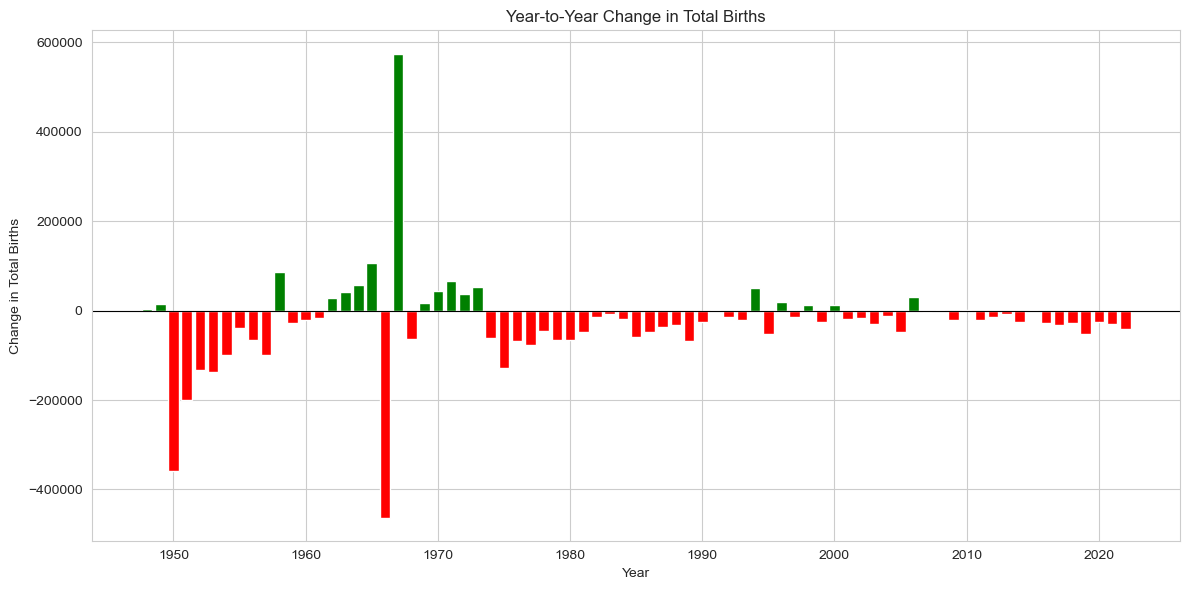

In [8]:
# =============================================================================
# Analysis 2 — Year-to-Year Change in Total Births
# =============================================================================
df['birth_change'] = df['birth_total'].diff()

plt.figure(figsize=(12, 6))
plt.bar(df['year'], df['birth_change'],
        color=['green' if x >= 0 else 'red' for x in df['birth_change']])
plt.xlabel('Year')
plt.ylabel('Change in Total Births')
plt.title('Year-to-Year Change in Total Births')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

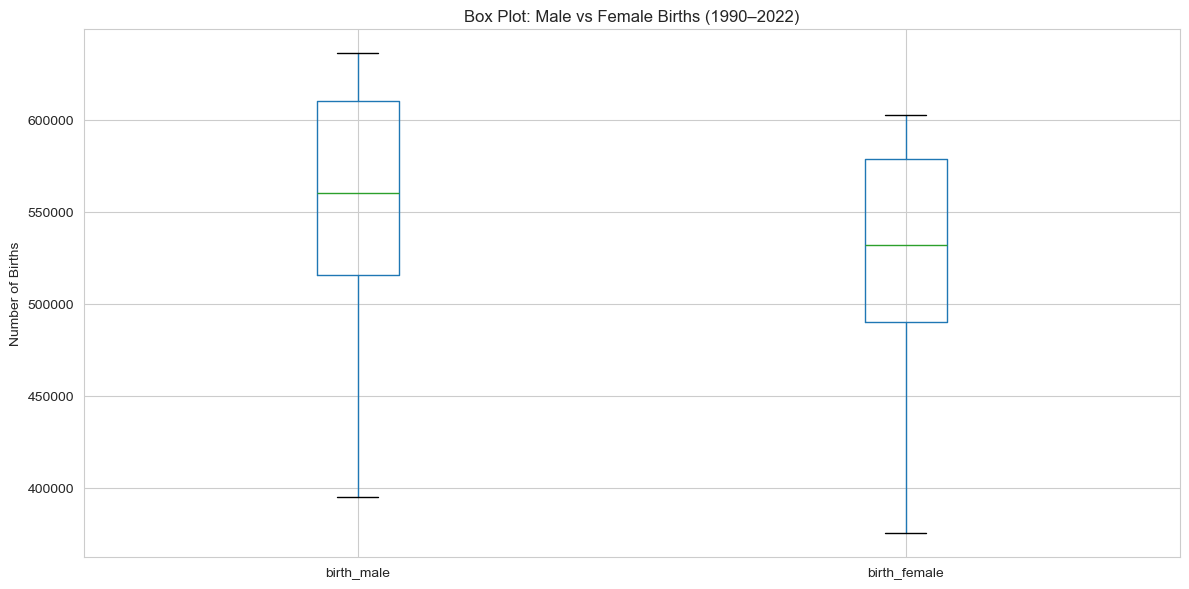

In [9]:
# =============================================================================
# Analysis 3 — Box Plot: Male vs Female Births (1990–2022)
# =============================================================================
df_filtered = df[(df['year'] >= 1990) & (df['year'] <= 2022)]

plt.figure(figsize=(12, 6))
df_filtered[['birth_male', 'birth_female']].boxplot()
plt.ylabel('Number of Births')
plt.title('Box Plot: Male vs Female Births (1990–2022)')
plt.tight_layout()
plt.show()


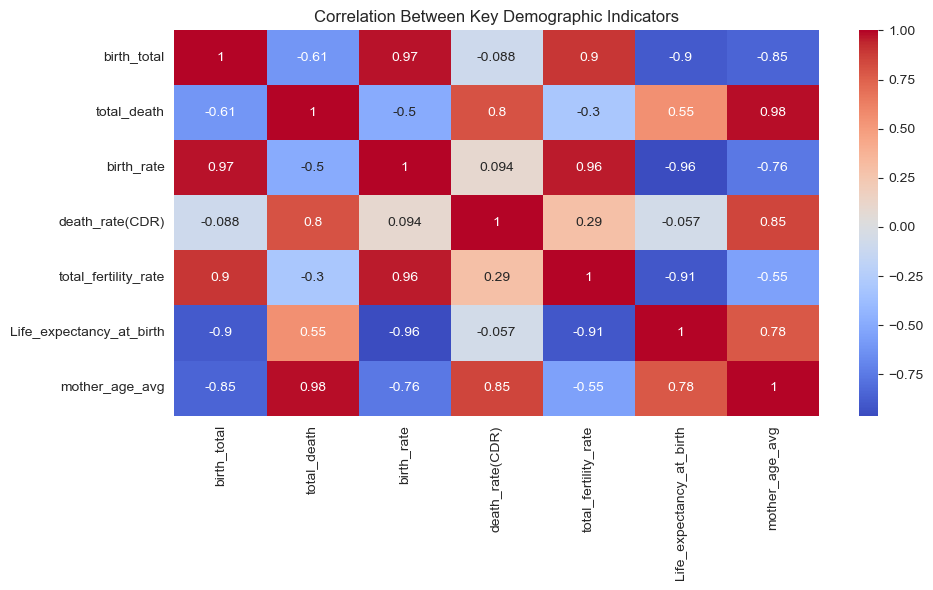

In [10]:
# =============================================================================
# Analysis 4 — Correlation Heatmap: Key Demographic Indicators
# =============================================================================
cols = [
    'birth_total', 'total_death', 'birth_rate',
    'death_rate(CDR)', 'total_fertility_rate',
    'Life_expectancy_at_birth', 'mother_age_avg'
]

plt.figure(figsize=(10, 6))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Key Demographic Indicators")
plt.tight_layout()
plt.show()

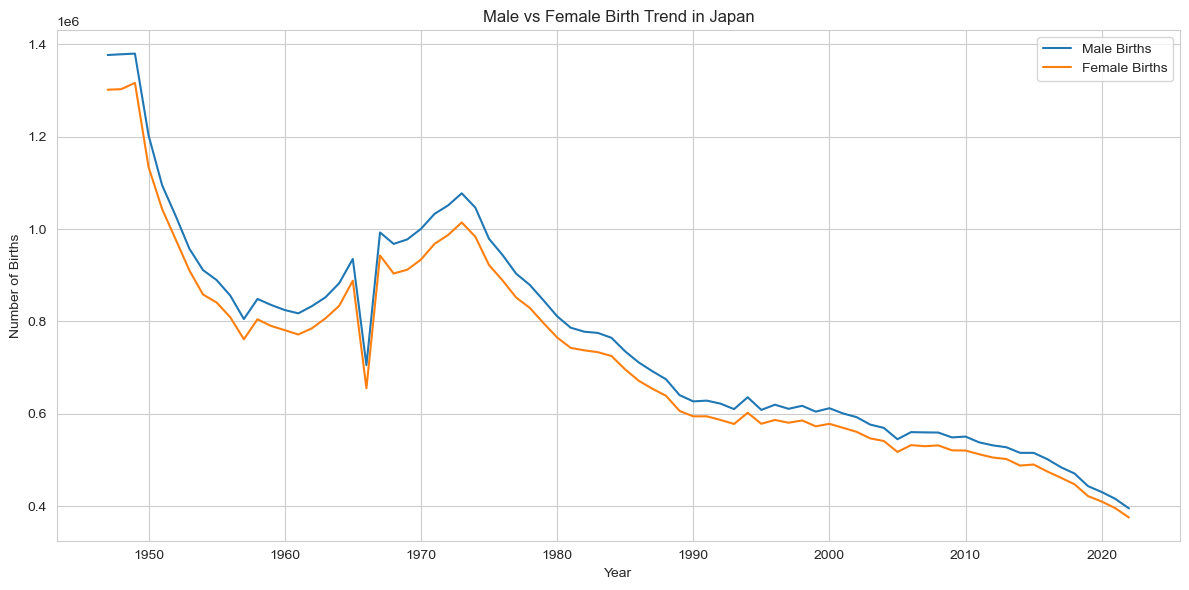

In [11]:
# =============================================================================
# Analysis 5 — Male vs Female Birth Trend
# =============================================================================
plt.figure(figsize=(12, 6))
plt.plot(df['year'], df['birth_male'], label='Male Births')
plt.plot(df['year'], df['birth_female'], label='Female Births')
plt.title("Male vs Female Birth Trend in Japan")
plt.xlabel("Year")
plt.ylabel("Number of Births")
plt.legend()
plt.tight_layout()
plt.show()

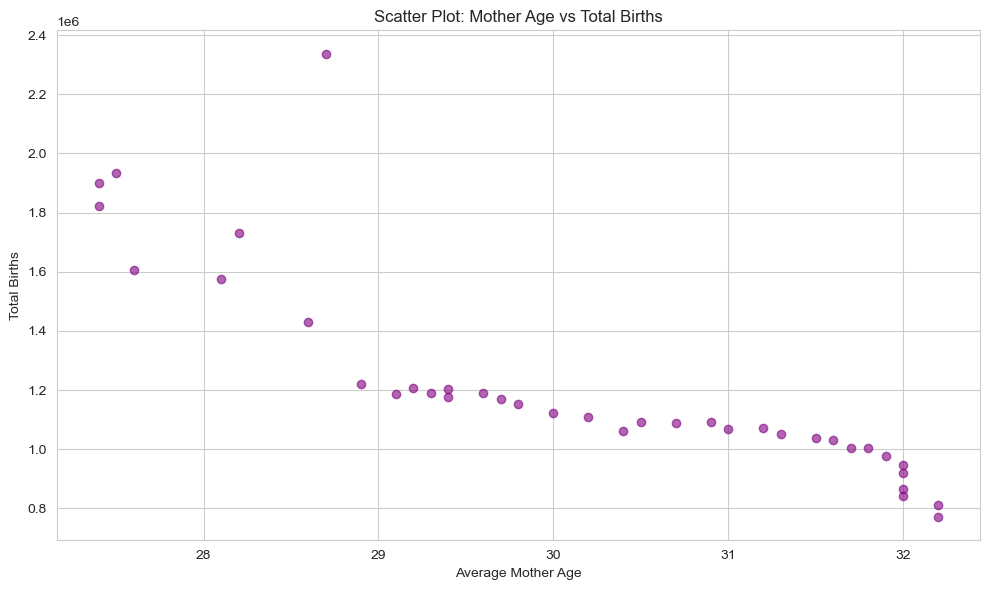

In [12]:
# =============================================================================
# Analysis 6 — Scatter Plot: Mother Age vs Total Births
# =============================================================================
plt.figure(figsize=(10, 6))
plt.scatter(df['mother_age_avg'], df['birth_total'], color='purple', alpha=0.6)
plt.xlabel('Average Mother Age')
plt.ylabel('Total Births')
plt.title('Scatter Plot: Mother Age vs Total Births')
plt.grid(True)
plt.tight_layout()
plt.show()

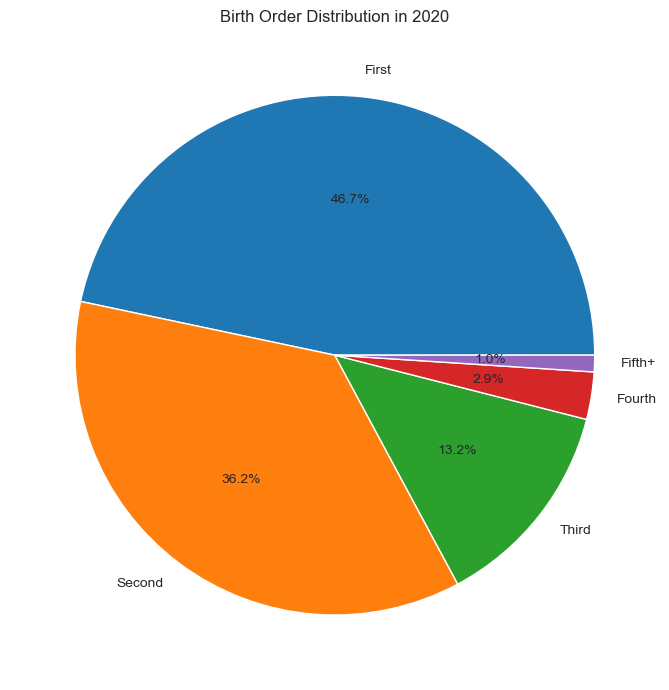

In [13]:
# =============================================================================
# Analysis 7 — Birth Order Distribution (2020)
# =============================================================================
year_selected = 2020
row = df[df['year'] == year_selected].iloc[0]

plt.figure(figsize=(7, 7))
plt.pie(
    [row['firstborn'], row['secondborn'], row['thirdborn'],
     row['forthborn'], row['fifthborn_and_above']],
    labels=['First', 'Second', 'Third', 'Fourth', 'Fifth+'],
    autopct='%1.1f%%'
)
plt.title(f"Birth Order Distribution in {year_selected}")
plt.tight_layout()
plt.show()

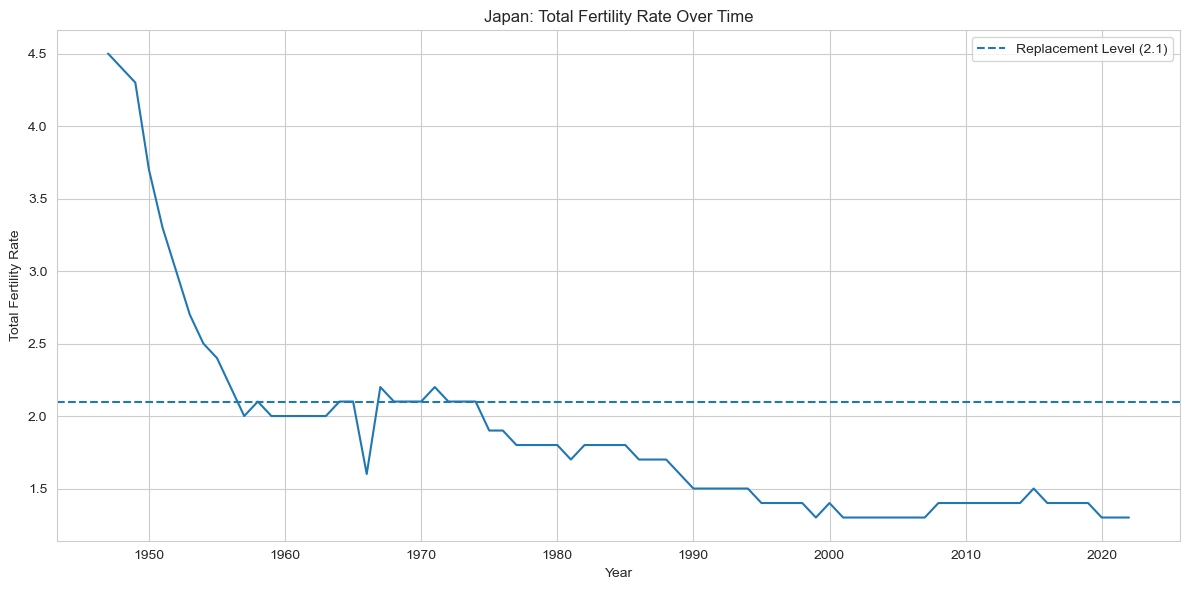

In [14]:
# =============================================================================
# Analysis 8 — Total Fertility Rate Over Time
# =============================================================================
plt.figure(figsize=(12, 6))
plt.plot(df['year'], df['total_fertility_rate'])
plt.axhline(2.1, linestyle='--', label='Replacement Level (2.1)')
plt.title("Japan: Total Fertility Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Total Fertility Rate")
plt.legend()
plt.tight_layout()
plt.show()

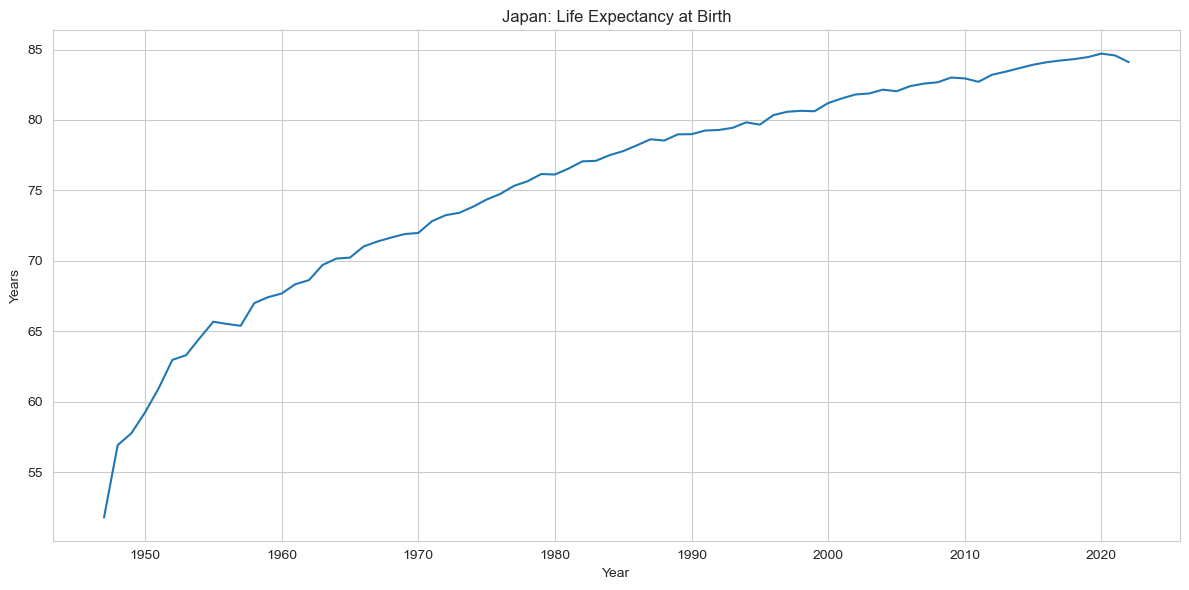

In [15]:
# =============================================================================
# Analysis 9 — Life Expectancy at Birth
# =============================================================================
plt.figure(figsize=(12, 6))
plt.plot(df['year'], df['Life_expectancy_at_birth'])
plt.title("Japan: Life Expectancy at Birth")
plt.xlabel("Year")
plt.ylabel("Years")
plt.tight_layout()
plt.show()

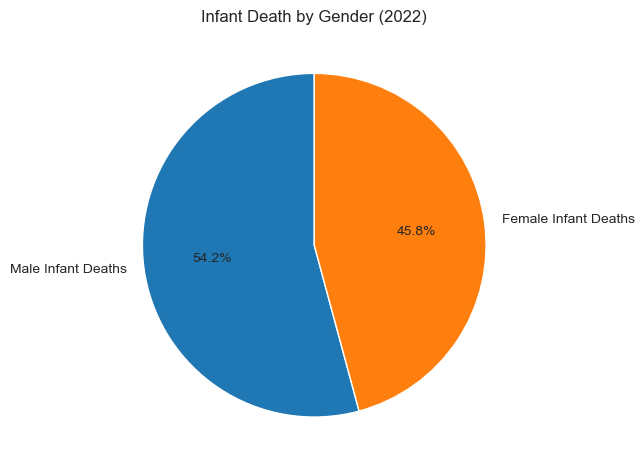

In [16]:
# =============================================================================
# Additional Analysis — Infant Death by Gender (2022)
# =============================================================================
data = [
    df.loc[df['year'] == 2022, 'infant_death_male'].values[0],
    df.loc[df['year'] == 2022, 'infant_death_female'].values[0]
]
plt.figure()
plt.pie(data, labels=['Male Infant Deaths', 'Female Infant Deaths'],
        autopct='%1.1f%%', startangle=90)
plt.title('Infant Death by Gender (2022)')
plt.tight_layout()
plt.show()

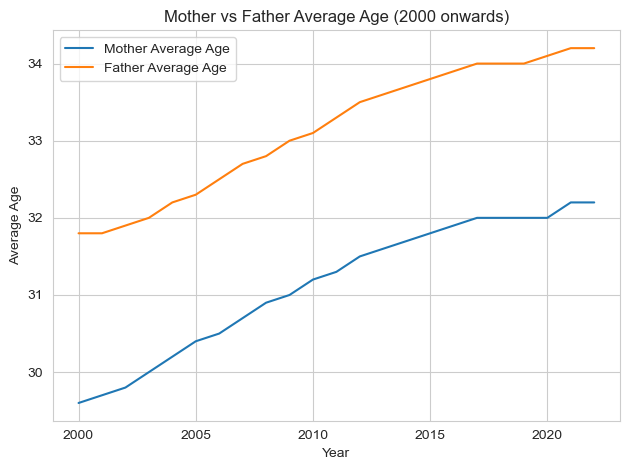

In [17]:
# =============================================================================
# Additional Analysis — Mother vs Father Average Age (2000 onwards)
# =============================================================================
df_2000 = df[df['year'] >= 2000]

plt.figure()
plt.plot(df_2000['year'], df_2000['mother_age_avg'], label='Mother Average Age')
plt.plot(df_2000['year'], df_2000['father_age_avg'], label='Father Average Age')
plt.xlabel('Year')
plt.ylabel('Average Age')
plt.title('Mother vs Father Average Age (2000 onwards)')
plt.legend()
plt.tight_layout()
plt.show()

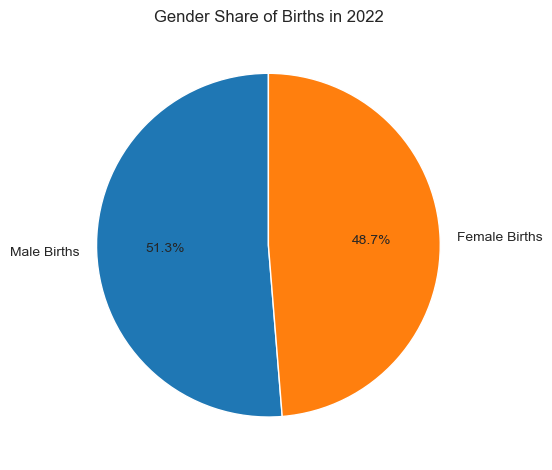

In [18]:
# =============================================================================
# Additional Analysis — Gender Share of Births (2022)
# =============================================================================
data = [
    df.loc[df['year'] == 2022, 'birth_male'].values[0],
    df.loc[df['year'] == 2022, 'birth_female'].values[0]
]
plt.figure()
plt.pie(data, labels=['Male Births', 'Female Births'],
        autopct='%1.1f%%', startangle=90)
plt.title('Gender Share of Births in 2022')
plt.tight_layout()
plt.show()

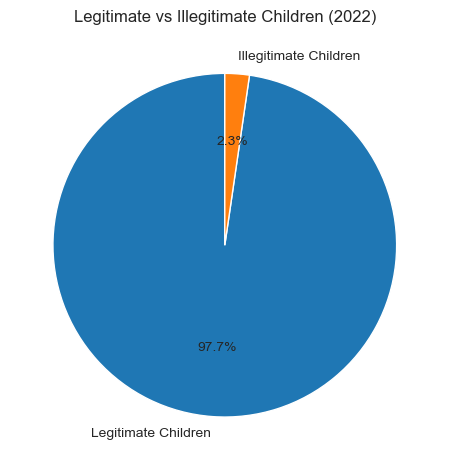

In [19]:
# =============================================================================
# Additional Analysis — Legitimate vs Illegitimate Children (2022)
# =============================================================================
data = [
    df.loc[df['year'] == 2022, 'legitimate_child'].values[0],
    df.loc[df['year'] == 2022, 'illegitimate_child'].values[0]
]
plt.figure()
plt.pie(data, labels=['Legitimate Children', 'Illegitimate Children'],
        autopct='%1.1f%%', startangle=90)
plt.title('Legitimate vs Illegitimate Children (2022)')
plt.tight_layout()
plt.show()